In [45]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 5.3 MB/s  0:00:02a 0:00:010:00:01:01

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [46]:
!pip install spacy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [47]:
!pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [48]:
import spacy
import os
import re
import pandas as pd
from collections import Counter

pattern = r'(?<!e\.g)(?<!i\.e)(?:\.|\?)(?=\s|$)'
nlp = spacy.load("en_core_web_sm")

In [49]:
# Single Test Example

with open("../_books/2026-02-22-humbug.md", "r") as f:
    lines = f.read().splitlines()
    sentences = [sentence.strip() for line in lines for sentence in re.split(pattern,line)]

sentence_counter = Counter()
pos_counter = Counter()
for sentence in sentences:
    doc = nlp(sentence)
    print(sentence)
    sentence_pos = []
    for token in doc:
        sentence_pos.append(token.pos_)
        pos_counter[token.pos_] += 1
    print(" ".join(sentence_pos))
    sentence_counter[" ".join(sentence_pos)] += 1
    print("-"*30)

---
PUNCT
------------------------------
date:             2026-02-22
NOUN PUNCT SPACE NUM PUNCT NUM SYM NUM
------------------------------
last_modified_at: 2026-04-08
X PUNCT NUM PUNCT NUM SYM NUM
------------------------------
tags:             [philosophy, truth]
NOUN PUNCT SPACE X NOUN PUNCT NOUN PUNCT
------------------------------
title:            Humbug and Bullshit
NOUN PUNCT SPACE PROPN CCONJ PROPN
------------------------------
name:             Humbug & Bullshit
NOUN PUNCT SPACE PROPN CCONJ PROPN
------------------------------
layout:           style
PROPN PUNCT SPACE NOUN
------------------------------
description:  >-
NOUN PUNCT SPACE X PUNCT
------------------------------
A reflective reading of Humbug, exploring skepticism, intellectual posturing, and how jargon can obscure rather than clarify meaning
DET ADJ NOUN ADP PROPN PUNCT VERB NOUN PUNCT ADJ NOUN PUNCT CCONJ SCONJ PROPN AUX VERB ADV ADP VERB VERB
------------------------------


------------------------------
c

In [50]:
sentence_counter.most_common(10)

[('', 21),
 ('PUNCT', 3),
 ('NOUN PUNCT SPACE PROPN CCONJ PROPN', 2),
 ('SYM NOUN NOUN', 2),
 ('NOUN PUNCT SPACE NUM PUNCT NUM SYM NUM', 1),
 ('X PUNCT NUM PUNCT NUM SYM NUM', 1),
 ('NOUN PUNCT SPACE X NOUN PUNCT NOUN PUNCT', 1),
 ('PROPN PUNCT SPACE NOUN', 1),
 ('NOUN PUNCT SPACE X PUNCT', 1),
 ('DET ADJ NOUN ADP PROPN PUNCT VERB NOUN PUNCT ADJ NOUN PUNCT CCONJ SCONJ PROPN AUX VERB ADV ADP VERB VERB',
  1)]

In [51]:
pos_counter.most_common(10)

[('NOUN', 124),
 ('PUNCT', 82),
 ('VERB', 60),
 ('ADP', 58),
 ('ADJ', 44),
 ('DET', 41),
 ('PRON', 37),
 ('PROPN', 28),
 ('AUX', 27),
 ('CCONJ', 23)]

In [74]:
# Full run
dirs = ["/_books", "/_fun", "/_life", "/_work"]

sentence_counter = Counter()
pos_counter = Counter()

for path in dirs:
    for file in os.listdir(".." + path):
        if not (file.endswith(".md")): continue
        if file.startswith("."): continue
        with open(".." + path + "/" + file, "r") as f:
                print(file)
                lines = f.read().splitlines()
                sentences = [sentence.strip() for line in lines for sentence in re.split(pattern,line)]
                for sentence in sentences:
                    doc = nlp(sentence)
                    sentence_pos = []
                    for token in doc:
                        sentence_pos.append(token.pos_)
                        if token.text == "that":
                            print(token,file)
                        pos_counter[token.pos_] += 1
                    sentence_counter[" ".join(sentence_pos)] += 1

2024-07-30-et-al.md
that 2024-07-30-et-al.md
2024-05-18-living-high.md
that 2024-05-18-living-high.md
2024-07-19-what-time-is-this-place.md
that 2024-07-19-what-time-is-this-place.md
2024-07-21-jojo.md
2025-06-30-vibecoding.md
that 2025-06-30-vibecoding.md
that 2025-06-30-vibecoding.md
that 2025-06-30-vibecoding.md
that 2025-06-30-vibecoding.md
2025-11-21-being.md
that 2025-11-21-being.md
2024-06-01-the-art-of-listening.md
2024-07-17-homo-ludens.md
2024-10-19-loss.md
that 2024-10-19-loss.md
2025-02-22-fifth-discipline.md
2024-12-27-postman.md
that 2024-12-27-postman.md
2026-02-22-humbug.md
that 2026-02-22-humbug.md
that 2026-02-22-humbug.md
that 2026-02-22-humbug.md
2024-05-25-mans-search-for-meaning.md
that 2024-05-25-mans-search-for-meaning.md
that 2024-05-25-mans-search-for-meaning.md
that 2024-05-25-mans-search-for-meaning.md
2024-06-26-ways-of-seeing.md
that 2024-06-26-ways-of-seeing.md
2025-05-12-hbs.md
that 2025-05-12-hbs.md
that 2025-05-12-hbs.md
that 2025-05-12-hbs.md
2024-05-

In [53]:
sentence_counter.most_common(20)

[('', 2941),
 ('PUNCT', 271),
 ('NUM', 144),
 ('X PUNCT NUM PUNCT NUM SYM NUM', 95),
 ('PROPN PUNCT SPACE NOUN', 95),
 ('NOUN PUNCT SPACE X PUNCT', 94),
 ('NOUN PUNCT SPACE NUM SYM NUM SYM NUM', 72),
 ('SYM NOUN NOUN', 66),
 ('VERB PUNCT ADJ', 34),
 ('PUNCT NUM PUNCT', 32),
 ('NOUN PUNCT SPACE X NOUN PUNCT NOUN PUNCT', 28),
 ('NOUN PUNCT X PUNCT', 26),
 ('NOUN PUNCT SPACE PROPN PROPN', 24),
 ('NOUN PUNCT SPACE NUM PUNCT NUM SYM NUM', 24),
 ('NOUN', 24),
 ('PROPN', 22),
 ('SYM NOUN PROPN PROPN', 20),
 ('PROPN PUNCT NOUN', 15),
 ('PROPN PUNCT PROPN', 12),
 ('NOUN PUNCT SPACE X NOUN PUNCT NOUN PUNCT NOUN PUNCT', 11)]

In [54]:
pos_counter.most_common(10)

[('NOUN', 15270),
 ('PUNCT', 11594),
 ('VERB', 6961),
 ('ADP', 6169),
 ('DET', 5690),
 ('PRON', 4715),
 ('ADJ', 4503),
 ('PROPN', 4313),
 ('AUX', 3547),
 ('ADV', 2419)]

In [55]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
pos_counter.most_common(100)

[('NOUN', 15270),
 ('PUNCT', 11594),
 ('VERB', 6961),
 ('ADP', 6169),
 ('DET', 5690),
 ('PRON', 4715),
 ('ADJ', 4503),
 ('PROPN', 4313),
 ('AUX', 3547),
 ('ADV', 2419),
 ('CCONJ', 2067),
 ('PART', 1740),
 ('NUM', 1472),
 ('SCONJ', 1365),
 ('X', 1310),
 ('SYM', 1032),
 ('SPACE', 628),
 ('INTJ', 80)]

In [58]:
pos_counter

Counter({'NOUN': 15270,
         'PUNCT': 11594,
         'VERB': 6961,
         'ADP': 6169,
         'DET': 5690,
         'PRON': 4715,
         'ADJ': 4503,
         'PROPN': 4313,
         'AUX': 3547,
         'ADV': 2419,
         'CCONJ': 2067,
         'PART': 1740,
         'NUM': 1472,
         'SCONJ': 1365,
         'X': 1310,
         'SYM': 1032,
         'SPACE': 628,
         'INTJ': 80})

In [59]:
pos_df = pd.DataFrame.from_dict(pos_counter, orient="index", columns=["Count"])
pos_df = pos_df.reset_index().rename(columns={'index':'label'})
pos_df.sort_values(by="Count", inplace=True, ascending=False)
pos_df.head(5)

,label,Count
1,NOUN,15270
0,PUNCT,11594
10,VERB,6961
12,ADP,6169
14,DET,5690


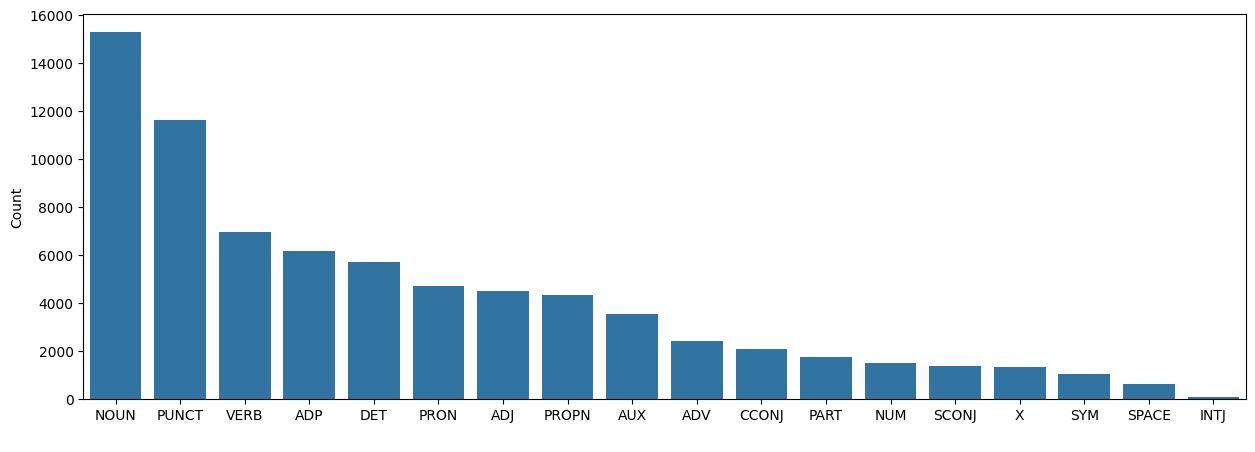

In [60]:
plt.figure(figsize=(15, 5))
plt.xlabel(" ")
sns.barplot(pos_df, x="label", y="Count")
plt.savefig("PoS_Barplot.png")

In [61]:
# Full run
dirs = ["/_books", "/_fun", "/_life", "/_work"]

data = []

for path in dirs:
    for file in os.listdir(".." + path):
        if not (file.endswith(".md")): continue
        with open(".." + path + "/" + file, "r") as f:
                print(file)
                lines = f.read().splitlines()
                sentences = [sentence.strip() for line in lines for sentence in re.split(pattern,line)]
                for sentence in sentences:
                    doc = nlp(sentence)
                    for token in doc:
                        data.append((token, token.pos_, path))


.2024-08-21-analytical-readings.md
.2025-10-11-heideigger.md
2024-07-30-et-al.md
2024-05-18-living-high.md
.2024-10-26-absent-body.md
2024-07-19-what-time-is-this-place.md
2024-07-21-jojo.md
2025-06-30-vibecoding.md
2025-11-21-being.md
.2024-10-19-on-earth.md
.2024-08-24-pedagogy-of-the-opressed.md
2024-06-01-the-art-of-listening.md
2024-07-17-homo-ludens.md
.2024-08-18-fuck-your-feelings.md
2024-10-19-loss.md
2025-02-22-fifth-discipline.md
2024-12-27-postman.md
2026-02-22-humbug.md
.2024-08-17-the-presentation-of-self.md
2024-05-25-mans-search-for-meaning.md
2024-06-26-ways-of-seeing.md
2025-05-12-hbs.md
2024-05-21-random-walk-down-ws.md
2025-02-25-worlds-in-plain-sight.md
.2025-01-01-democratizing-innovation.md
2024-07-10-mind-self.md
2025-09-14-katabasis.md
2024-07-13-rounds.md
.2025-03-07-eternal-sunshine.md
2025-04-09-typography.md
2025-04-13-photography.md
2024-08-30-guilty-gear-strive.md
2025-11-11-statemottos.md
2024-08-13-kind-words-2.md
2026-04-25-rvsp.md
2025-04-29-clairobsc

In [62]:
words_df = pd.DataFrame(data, columns=["word","pos","path"])
words_df.head(5)

,word,pos,path
0,---,PUNCT,/_books
1,date,NOUN,/_books
2,:,PUNCT,/_books
3,,SPACE,/_books
4,2024,NUM,/_books


In [71]:
pos_to_see = "ADV"
words_df["word"] = words_df["word"].apply(lambda x: str(x) if pd.notna(x) else x)
words_df["word"] = words_df["word"].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)
words_df[words_df["pos"] == pos_to_see][["word"]].value_counts()[:15]

word   
even       103
so          99
then        93
more        79
here        69
|           67
only        61
also        58
well        47
now         42
however     39
^2          38
back        36
never       36
still       35
Name: count, dtype: int64

In [64]:
# Full run
dirs = ["/_books", "/_fun", "/_life", "/_work"]

data = []

def sentence_phrase_pairs(text):
    doc = nlp(text)
    pairs = []
    for sent in doc.sents:
        # get phrases (here: noun chunks; adapt to other phrase types)
        phrases = [chunk.text.strip() for chunk in sent.noun_chunks]
        for phrase in phrases:
            pairs.append(phrase)
    return pairs

for path in dirs:
    for file in os.listdir(".." + path):
        if not (file.endswith(".md")): continue
        with open(".." + path + "/" + file, "r") as f:
                print(file)
                lines = f.read()
                sentences = sentence_phrase_pairs(lines)
                for pair in sentences:
                    pair_pos = []
                    doc = nlp(pair)
                    for token in doc:
                        pair_pos.append(token.pos_)
                    print((" ".join(pair_pos)))
                    data.append((" ".join(pair_pos), pair, path, file))

.2024-08-21-analytical-readings.md
PUNCT SPACE NOUN
NUM SYM NUM SYM NUM SPACE NOUN
NUM PUNCT NUM PUNCT NUM SPACE NOUN
PROPN PROPN SPACE NOUN
PROPN PROPN SPACE NOUN
NOUN SPACE NOUN
ADV
PRON
PRON NOUN NOUN
ADJ SPACE PUNCT SPACE NOUN PROPN NOUN
PROPN PROPN SPACE PUNCT NOUN
NOUN
NOUN SPACE PUNCT NOUN
NOUN
VERB
NOUN
VERB
NOUN
NOUN SPACE SYM NOUN NOUN
PRON
DET NOUN
PRON
PRON
ADV NUM NOUN
NUM PROPN
PRON
ADJ
VERB
NOUN
PRON NOUN
NUM NOUN
PRON
PRON
DET ADJ NOUN
PRON
.2025-10-11-heideigger.md
PUNCT SPACE NOUN
NUM SYM NUM SYM NUM SPACE NOUN
NUM PUNCT NUM PUNCT NUM SPACE NOUN
NOUN PUNCT PROPN PUNCT PROPN PUNCT NOUN PUNCT NOUN PUNCT NOUN PUNCT SPACE NOUN
NOUN SPACE NOUN
NUM PROPN PROPN
NOUN SPACE NOUN
PUNCT SPACE NOUN
NOUN
PRON NOUN
PUNCT SPACE NOUN NUM PROPN PROPN
VERB
VERB
PRON NOUN VERB
PRON
DET NOUN
PRON
DET NOUN
PRON ADJ NOUN
NOUN
PRON
PRON
PROPN
PRON
PRON
PROPN
DET ADJ NOUN
PRON
PROPN
ADJ NOUN
ADV ADJ NOUN
PRON
DET NOUN
DET PROPN NOUN
SCONJ
DET NOUN
PRON
PRON
DET NOUN
PRON NOUN
PRON
DET NUM NO

In [65]:
sentence_df = pd.DataFrame(data, columns=["pair","real_pair","path","file"])
sentence_df = sentence_df[(sentence_df["pair"] != "")]
sentence_df.head(5)

,pair,real_pair,path,file
0,PUNCT SPACE NOUN,---\ndate,/_books,.2024-08-21-analytical-readings.md
1,NUM SYM NUM SYM NUM SPACE NOUN,2024-08-21\nlast_modified_at,/_books,.2024-08-21-analytical-readings.md
2,NUM PUNCT NUM PUNCT NUM SPACE NOUN,2026-04-08\ntags,/_books,.2024-08-21-analytical-readings.md
3,PROPN PROPN SPACE NOUN,Analytical Readings\nname,/_books,.2024-08-21-analytical-readings.md
4,PROPN PROPN SPACE NOUN,Analytical Readings\nlayout,/_books,.2024-08-21-analytical-readings.md


In [66]:
sentence_df["pair"].value_counts()[:20]

pair
PRON                                  3531
DET NOUN                              3132
NOUN                                  2865
DET ADJ NOUN                           820
ADJ NOUN                               689
PROPN                                  600
PRON NOUN                              382
NOUN NOUN                              363
PROPN PROPN                            259
DET NOUN NOUN                          259
SCONJ                                  254
VERB                                   250
PUNCT                                  212
NOUN SPACE NOUN                        112
PROPN NOUN                             110
PUNCT SPACE NOUN                       109
PRON ADJ NOUN                          101
NUM PUNCT NUM PUNCT NUM SPACE NOUN      91
DET PROPN                               78
INTJ                                    78
Name: count, dtype: int64

In [67]:
sentence_df[sentence_df["real_pair"].str.contains("just", na=False)][["real_pair","file"]]

,real_pair,file
152,justice,.2025-10-11-heideigger.md
165,justice,.2025-10-11-heideigger.md
362,"a ""*Libertarian*"" justification",2024-05-18-living-high.md
2666,maladjustment,2024-05-25-mans-search-for-meaning.md
5096,justice,2025-11-11-statemottos.md
8459,justice,.2024-10-25-clemon-series.md
9631,its primary justifications,.2024-10-23-great-philosophers.md
10359,just development,.2024-09-17-development.md
11014,just the existence,.2024-09-17-development.md
11112,justification,.2025-03-11-unbiased.md


In [68]:
sentence_df[sentence_df["pair"].str.contains(" AUX ", na=False)]

,pair,real_pair,path,file
1412,X NOUN PUNCT NOUN PUNCT AUX PUNCT SPACE NOUN,"[phenomenology, philosophy, being]\ntitle",/_books,2025-11-21-being.md
4845,SCONJ AUX PRON NOUN NOUN,How does your playstyle change,/_fun,2024-08-30-guilty-gear-strive.md
11505,NUM ADV AUX PUNCT NUM ADV ADV PUNCT NUM NOUN,66 | would : 135 | well : 57 |,/_life,2026-04-04-mystyle.md
13227,PRON NOUN NOUN AUX NOUN,their navigation hierarchy prevents overload,/_work,2025-03-26-neocities.md
13252,X SYM SCONJ PUNCT PRON PUNCT NOUN PUNCT AUX PU...,14kb](https://endtimes.dev/why-your-website-sh...,/_work,2025-03-26-neocities.md
16341,PART ADV AUX PUNCT VERB,Not only did *Crowdstrike,/_work,2024-07-21-how-complex-systems-fail.md
17264,PRON AUX NOUN,it's behaviour,/_work,.2025-09-01-syseng.md


In [69]:
# Single Test Example

with open("../mainpages/about.md", "r") as f:
    lines = f.read().splitlines()
    sentences = [sentence.strip() for line in lines for sentence in re.split(pattern,line)]

sentence_counter = Counter()
pos_counter = Counter()
for sentence in sentences:
    doc = nlp(sentence)
    sentence_pos = []
    sentence_debug = []
    for token in doc:
        if token.pos_ == "AUX" or token.pos_ == "ADV" or token.pos_ == "SCONJ":
            sentence_debug.append("[" + token.text + "]")
            sentence_pos.append(token.pos_ + ":" + token.text)
        else: 
            sentence_debug.append(token.text)
            sentence_pos.append(token.pos_)
       
        pos_counter[token.pos_] += 1
    print(" ".join(sentence_debug))
    print(" ".join(sentence_pos))
    sentence_counter[" ".join(sentence_pos)] += 1
    print("-"*30)

---
PUNCT
------------------------------
categories :        blog
NOUN PUNCT SPACE NOUN
------------------------------
date :              2024 - 07 - 14
NOUN PUNCT SPACE NUM PUNCT NUM SYM NUM
------------------------------
last_modified_at : 2026 - 04 - 08
X PUNCT NUM PUNCT NUM SYM NUM
------------------------------
tags : [ aboutme , reflection ]
NOUN PUNCT X NOUN PUNCT NOUN PUNCT
------------------------------
description :   > -
NOUN PUNCT SPACE X PUNCT
------------------------------
who i [am] and [why] i started blogging
PRON PRON AUX:am CCONJ SCONJ:why PRON VERB VERB
------------------------------
lang :              en
PROPN PUNCT SPACE VERB
------------------------------
last_modified_at : 2024 - 07 - 14
X PUNCT NUM PUNCT NUM SYM NUM
------------------------------
layout :            style
PROPN PUNCT SPACE NOUN
------------------------------
title : > -
NOUN PUNCT X PUNCT
------------------------------
[About]
ADV:About
------------------------------
permalink : /about/
VERB 